# 2. Feature Engineering

Import Packages

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## 2.1 Data Loading and Sanity Checks

Load the cleaned df from 01_exploration

In [140]:
# ============================================================
# Load cleaned dataset
# ============================================================

df = pd.read_csv("../data/processed/bitcoin_cleaned_after_exploration.csv")

df["date"] = pd.to_datetime(df["date"])

print(df.shape)
print(df["date"].min())
print(df["date"].max())

df.head()

(5427, 14)
2011-04-24 00:00:00
2026-03-02 00:00:00


,date,active_addresses,nonzero_addresses,mvrv_ratio,total_fees_btc,exchange_inflow_usd,exchange_outflow_usd,hash_rate,issuance_usd,price_usd,exchange_supply_btc,transaction_count,transfer_count,spot_volume_usd
0,2011-04-24,4821.0,96648.0,4.275436,4.722223,228.477791,0.0,0.743681,13219.072180,1.631984,140.0,2291.0,4655.0,36076.006302
1,2011-04-25,5053.0,97115.0,4.061132,8.931643,0.000000,0.0,0.881400,15019.042899,1.564484,140.0,2342.0,5163.0,21226.889728
2,2011-04-26,6053.0,97408.0,4.514597,4.990500,0.000000,0.0,0.895172,17265.698679,1.770841,140.0,3203.0,6771.0,40211.166904
3,2011-04-27,7488.0,97696.0,4.767442,9.171679,0.000000,0.0,0.840084,17414.060020,1.903176,140.0,4394.0,8927.0,62403.354408
4,2011-04-28,6130.0,98142.0,5.535625,6.610500,0.000000,0.0,0.752862,18743.104620,2.285744,140.0,2819.0,5761.0,203392.458484


Quick Sanity Checks

In [141]:
# ============================================================
# Quick sanity check
# ============================================================

print(df.columns.tolist())

df.isna().sum().sort_values(ascending=False)

['date', 'active_addresses', 'nonzero_addresses', 'mvrv_ratio', 'total_fees_btc', 'exchange_inflow_usd', 'exchange_outflow_usd', 'hash_rate', 'issuance_usd', 'price_usd', 'exchange_supply_btc', 'transaction_count', 'transfer_count', 'spot_volume_usd']


date                    0
active_addresses        0
nonzero_addresses       0
mvrv_ratio              0
total_fees_btc          0
exchange_inflow_usd     0
exchange_outflow_usd    0
hash_rate               0
issuance_usd            0
price_usd               0
exchange_supply_btc     0
transaction_count       0
transfer_count          0
spot_volume_usd         0
dtype: int64

In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5427 entries, 0 to 5426
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  5427 non-null   datetime64[us]
 1   active_addresses      5427 non-null   float64       
 2   nonzero_addresses     5427 non-null   float64       
 3   mvrv_ratio            5427 non-null   float64       
 4   total_fees_btc        5427 non-null   float64       
 5   exchange_inflow_usd   5427 non-null   float64       
 6   exchange_outflow_usd  5427 non-null   float64       
 7   hash_rate             5427 non-null   float64       
 8   issuance_usd          5427 non-null   float64       
 9   price_usd             5427 non-null   float64       
 10  exchange_supply_btc   5427 non-null   float64       
 11  transaction_count     5427 non-null   float64       
 12  transfer_count        5427 non-null   float64       
 13  spot_volume_usd       5427 no

## 2.2 Creating Features

The Exploration Analysis in 01 revelead the following recommended transformations:


| Variable | Keep? | Transformation (tentative) | Time Restriction | Notes |
|-----------|--------|---------------------------|------------------|--------|
| active_addresses | KEEP | Growth OR rolling Z-Score | Exclude pre-2016 | 2nd Option Exclude pre-2016 and take Levels, might work |
| nonzero_addresses | KEEP | Growth OR rolling Z-Score | Exclude pre-2016 | - |
| block_count | DELETE | - | - | Mostly protocol randomness/noise, no clear economic meaning |
| transaction_count | KEEP | Growth (possibly MA) OR rolling Z-Score | Unclear, possibly exclude pre-2016 | - |
| transfer_count | KEEP | Growth (possibly MA) OR rolling Z-Score | Exclude pre-2016 | - |
| hash_rate | KEEP | Growth OR rolling Z-Score | Unclear, possibly exclude pre-2016 | -|
| total_fees_btc | KEEP | None, keep Level | None | - |
| issuance_usd | KEEP | Growth (possibly MA) OR rolling Z-Score | Unclear, possibly exclude pre-2016 | Care, possibly redundant since Prod-function x Price with possible level-shift signals |
| exchange_supply_btc | KEEP | Growth (possibly MA) OR rolling Z-Score | None | - |
| exchange_inflow_usd | KEEP | Growth (possibly MA) OR rolling Z-Score | Unclear, possibly exclude pre-2016 | - |
| exchange_outflow_usd | KEEP | Growth (possibly MA) OR rolling Z-Score | Unclear, possibly exclude pre-2016 | - |
| price_usd | KEEP | Growth (possibly MA) OR rolling Z-Score | Unclear, possibly exclude pre-2016 | - |
| mvrv_ratio | KEEP | None, keep Level | None or pre-2012 | 2nd Option if not working well, take Growth |
| spot_volume_usd | KEEP | Growth (possibly MA) OR rolling Z-Score | Unclear, possibly exclude pre-2016 | - |

Based on the Analysis above, I will build the corresponding features. The core question here is not only growth rate vs Rolling Z-Score, but which time frame I should take to build the features, as I could take growth rates over 30, 90, 180 days or even 1 year +;

- Is 30d already enough to capture regimes and regime changes, or do I need to take more?
- Even if I would know what would be the ideal time frame, should I keep it the same for all variable transformations (that need transformation) or should I adjust them individually?
- And even if so, should I incorporate Moving Average (MA) transformations prior to calculating the growth rates such that I minimize noise and make it less dependent on randomness?
- and if I take the MA approach, what kind of MA do I use then? do I average out by 30 days, 90 days? Even more? The same time frame as I do the growth rates based on, or another? Would another Averaging Method even be better, f.e. Exponential Moving Averages (EMAs)?

In this chapter, I will try to come up with questions to these answers. The difficulty here lies in not knowing what will actually work the best, while also not having a definitive 'correct' answer - these things are completely data-dependent. Depending on the results, I might revisit this section again and change things here and there, but for now, I will try to choose what makes the most sense based on the previous exploration and the feeling I got for the data.

### Core Plan for the Engineering

In order to truly find out what works best, there is no other way around than testing it. Therefore, I will not only create 1 dataset, but 3 datasets with 3 different feature engineering approaches:

- I rule out the 30d window for growth rates as it should be too short-term to represent regimes. Instead, I think 90d, 180d and 365d should be suitable. I will therefore use 90d and 180d growth rates and use a rolling Z-Score approach for the 365 approach, as it works better with more datapoints anyways.

- I decided to not build 'individual features' for each variable that needs transformation (i.e. here 90d, there 30d, here 180d) but to use the same length for all variables that need transformation - I do not know what will work best and trying to engineering here into individual details would therefore not make sense.

- The analysis revelealed that most variables that need transformation are suffering from heavy fluctuations that would cause likely much noise when being used for calculating growth rates based on 2 values only (one in t, one in t-1). Since I want to find regimes and clear structure and not random spikes, my approach is to minimize these fluctuations without loosing the core mid-to-longterm structure. I therefore apply MA transformation before deriving growth rates and decided to use 30d MAs. The decision here balances a smoothing of high fluctuations (and as such noise reduction) without actually smoothing out the resulting growth rates (the signal for regimes) too much as well.

- According to my analysis, not all variables would necessitate the MA smoothing, but most do. I chose to go for the MA-approach universally for all variables that do need transformation with a growth rate (Rolling Z-Score does not necessarily need external smoothing as it smoothes it itself to some extend by incorporating the standard deviation of a period and deriving the Z-Score).

- Since many variables look not very promising once when the pre-2016 data is incorporated, I will exclude it. This step will happen BEFORE creating the features so that, depending on the approach, the dataset will have NA features for 119, 209 or 364 observations (X + 30 for MA, 364 for Rolling Z). These observations will be excluded afterwards, resulting in 3 datasets with different amounts of observations. This is completely fine, as it represents the best possible datasets for each. The alternatives of f.e. a) artifically starting at 2017 or b) cutting the earlier data AFTER transformation are dropped since a) does only cut away unnecessary good data for some appraoches and b) would again incorporate unsuitable data into the features by taking it into account as a t-1, lowering data quality again.

Importantly, the two variables that do not need transformation (mvrv and bitcoin fees) will be kept in Levels and will NOT be transformed, applies for every dataset.

**The Datasets**:

1) **Feature Set A**: 90d growth rate based on 30d MAs for t and t-1; dataset post 2015 - 120 observations - Capturing how much things changed in a 'shorter' period

2) **Feature Set B**: 180d growth rate based on 30d MAs for t and t-1; dataset post 2015 - 210 observations - Capturing how much things changed in a 'longer' period

3) **Feature Set C**: Rolling Z-Scores of 365 observations; dataset post 2015 - 364 observations - Capturing how special something is compared to its past


In the next steps, I will create these features and datasets.

### Engineering

First, I cut the data to exclude any pre-2016 observations:

In [143]:
# ============================================================
# Restrict sample to post-2016 period
# ============================================================

df_2016 = df[df["date"] >= "2016-01-01"].copy()

print("Original observations:", len(df))
print("Post-2016 observations:", len(df_2016))
print("First date:", df_2016["date"].min())
print("Last date:", df_2016["date"].max())

Original observations: 5427
Post-2016 observations: 3714
First date: 2016-01-01 00:00:00
Last date: 2026-03-02 00:00:00


Next the helper functions for growth rates including MA-transformations and Rolling Z-Scores

In [144]:
# ============================================================
# Feature engineering helper functions
# ============================================================

def ma_pct_growth(data, columns, ma_window=30, growth_window=90):
    """
    Computes percentage growth of moving average:
    (MA_t / MA_t-growth_window) - 1
    """
    features = pd.DataFrame(index=data.index)
    features["date"] = data["date"]

    for col in columns:
        ma = data[col].rolling(ma_window).mean()
        features[f"{col}_ma{ma_window}_g{growth_window}d"] = (ma / ma.shift(growth_window)) - 1

    return features


def rolling_zscore(data, columns, window=365):
    """
    Computes rolling z-score:
    (x_t - rolling_mean) / rolling_std
    """
    features = pd.DataFrame(index=data.index)
    features["date"] = data["date"]

    for col in columns:
        rolling_mean = data[col].rolling(window).mean()
        rolling_std = data[col].rolling(window).std()
        features[f"{col}_z{window}d"] = (data[col] - rolling_mean) / rolling_std

    return features

Variable Definition for Transformation, excluding mvrv and bitcoin fees:

In [145]:
# ============================================================
# Define variables for transformation
# ============================================================

growth_columns = [
    "active_addresses",
    "nonzero_addresses",
    "transaction_count",
    "transfer_count",
    "hash_rate",
    "issuance_usd",
    "exchange_supply_btc",
    "exchange_inflow_usd",
    "exchange_outflow_usd",
    "price_usd",
    "spot_volume_usd"
]

level_columns = [
    "mvrv_ratio",
    "total_fees_btc"
]

#### Creation of Feature Set A (90d Growth and 30d MA)

In [146]:
# ============================================================
# Feature Set A: 90d percentage growth of 30d moving average
# ============================================================

features_90d = ma_pct_growth(
    data=df_2016,
    columns=growth_columns,
    ma_window=30,
    growth_window=90
)

features_90d = features_90d.merge(
    df_2016[["date"] + level_columns],
    on="date",
    how="left"
)

features_90d = features_90d.dropna().reset_index(drop=True)

print(features_90d.shape)
features_90d.head()

print("deleted observations due to transformations:", 3714 - len(features_90d), "| Should be 119")

(3595, 14)
deleted observations due to transformations: 119 | Should be 119


#### Creation of Feature Set B (180d Growth and 30d MA)

In [147]:
# ============================================================
# Feature Set B: 180d percentage growth of 30d moving average
# ============================================================

features_180d = ma_pct_growth(
    data=df_2016,
    columns=growth_columns,
    ma_window=30,
    growth_window=180
)

features_180d = features_180d.merge(
    df_2016[["date"] + level_columns],
    on="date",
    how="left"
)

features_180d = features_180d.dropna().reset_index(drop=True)

print(features_180d.shape)
features_180d.head()

print("deleted observations due to transformations:", 3714 - len(features_180d), "| Should be 209")

(3505, 14)
deleted observations due to transformations: 209 | Should be 209


#### Creation of Feature Set C (365d Rolling Z-Scores)

In [148]:
# ============================================================
# Feature Set C: 365d rolling z-score
# ============================================================

features_z365 = rolling_zscore(
    data=df_2016,
    columns=growth_columns,
    window=365
)

features_z365 = features_z365.merge(
    df_2016[["date"] + level_columns],
    on="date",
    how="left"
)

features_z365 = features_z365.dropna().reset_index(drop=True)

print(features_z365.shape)
features_z365.head()

print("deleted observations due to transformations:", 3714 - len(features_z365), "| Should be 364")

(3350, 14)
deleted observations due to transformations: 364 | Should be 364


In [149]:
# ============================================================
# Save engineered feature sets
# ============================================================

features_90d.to_csv(
    "../data/processed/features_90d_growth_ma30.csv",
    index=False
)

features_180d.to_csv(
    "../data/processed/features_180d_growth_ma30.csv",
    index=False
)

features_z365.to_csv(
    "../data/processed/features_z365.csv",
    index=False
)

print("Feature sets saved.")

Feature sets saved.


Feature Engineering is, with this step, finished. Next I will do a feature validation step to see if the engineered features really make sense compared to the raw data.

## 2.3 Feature Validation

This step is here to check again the transformed data before its dimensionality is reduced and clustered. I will go through all 3 datasets and quickly check for each ALL histograms and timeseries. The key questions here are:

**Histograms**:
- Are the distributions plausible?
- Is there still structure left, or does it look like random noise?
- Are there any absurd values?

**Timeseries**:
- Are the trends gone - do we have approx. stationarity?
- Can one still see possible regimes over time?
- Are things too extrapolated by MAs, Growthrates and Z-Scores?

For that, I will build grids comparing the raw variable histogram and timeseries to the ones within the 3 datasets.

First, Helper Functions for Histograms and Timeseries grids per Dataset:

### Helper Functions

Mapping

In [150]:
# ============================================================
# Variable mapping
# ============================================================

raw_df = df_2016.copy()

comparison_map = {
    "active_addresses": {
        "raw": "active_addresses",
        "90d": "active_addresses_ma30_g90d",
        "180d": "active_addresses_ma30_g180d",
        "z365": "active_addresses_z365d"
    },
    "nonzero_addresses": {
            "raw": "nonzero_addresses",
            "90d": "nonzero_addresses_ma30_g90d",
            "180d": "nonzero_addresses_ma30_g180d",
            "z365": "nonzero_addresses_z365d"
        },
    "transaction_count": {
        "raw": "transaction_count",
        "90d": "transaction_count_ma30_g90d",
        "180d": "transaction_count_ma30_g180d",
        "z365": "transaction_count_z365d"
    },
    "transfer_count": {
        "raw": "transfer_count",
        "90d": "transfer_count_ma30_g90d",
        "180d": "transfer_count_ma30_g180d",
        "z365": "transfer_count_z365d"
    },
    "hash_rate": {
        "raw": "hash_rate",
        "90d": "hash_rate_ma30_g90d",
        "180d": "hash_rate_ma30_g180d",
        "z365": "hash_rate_z365d"
    },
    "issuance_usd": {
        "raw": "issuance_usd",
        "90d": "issuance_usd_ma30_g90d",
        "180d": "issuance_usd_ma30_g180d",
        "z365": "issuance_usd_z365d"
    },
    "exchange_supply_btc": {
        "raw": "exchange_supply_btc",
        "90d": "exchange_supply_btc_ma30_g90d",
        "180d": "exchange_supply_btc_ma30_g180d",
        "z365": "exchange_supply_btc_z365d"
    },
    "exchange_inflow_usd": {
        "raw": "exchange_inflow_usd",
        "90d": "exchange_inflow_usd_ma30_g90d",
        "180d": "exchange_inflow_usd_ma30_g180d",
        "z365": "exchange_inflow_usd_z365d"
    },
    "exchange_outflow_usd": {
        "raw": "exchange_outflow_usd",
        "90d": "exchange_outflow_usd_ma30_g90d",
        "180d": "exchange_outflow_usd_ma30_g180d",
        "z365": "exchange_outflow_usd_z365d"
    },
    "price_usd": {
        "raw": "price_usd",
        "90d": "price_usd_ma30_g90d",
        "180d": "price_usd_ma30_g180d",
        "z365": "price_usd_z365d"
    },
    "spot_volume_usd": {
        "raw": "spot_volume_usd",
        "90d": "spot_volume_usd_ma30_g90d",
        "180d": "spot_volume_usd_ma30_g180d",
        "z365": "spot_volume_usd_z365d"
    },
    "mvrv_ratio": {
        "raw": "mvrv_ratio",
        "90d": "mvrv_ratio",
        "180d": "mvrv_ratio",
        "z365": "mvrv_ratio"
    },
    "total_fees_btc": {
        "raw": "total_fees_btc",
        "90d": "total_fees_btc",
        "180d": "total_fees_btc",
        "z365": "total_fees_btc"
    }
}

Build series

In [151]:
# ============================================================
# Helper function
# ============================================================

def get_series(variable, version):

    col = comparison_map[variable][version]

    if version == "raw":
        temp = raw_df[["date", col]].dropna()

    elif version == "90d":
        temp = features_90d[["date", col]].dropna()

    elif version == "180d":
        temp = features_180d[["date", col]].dropna()

    elif version == "z365":
        temp = features_z365[["date", col]].dropna()

    return temp["date"], temp[col]

Histogram Comparison Helper

In [152]:
# ============================================================
# Histogram comparison
# ============================================================

def plot_histogram_comparison(variables):

    versions = ["raw", "90d", "180d", "z365"]

    column_titles = [
        "Raw",
        "90d Growth",
        "180d Growth",
        "365d Z-Score"
    ]

    fig, axes = plt.subplots(
        len(variables),
        len(versions),
        figsize=(20, 3 * len(variables))
    )

    for j, title in enumerate(column_titles):
        axes[0, j].set_title(
            title,
            fontsize=14,
            fontweight="bold"
        )

    for i, variable in enumerate(variables):

        for j, version in enumerate(versions):

            _, values = get_series(variable, version)

            sns.histplot(
                values,
                bins=50,
                ax=axes[i, j]
            )

            axes[i, j].set_xlabel("")
            axes[i, j].set_ylabel("")

        axes[i, 0].set_ylabel(
            variable,
            fontsize=11,
            fontweight="bold",
            rotation=0,
            labelpad=70
        )

    plt.subplots_adjust(
        hspace=0.6,
        wspace=0.35
    )

    plt.show()

Timeseries Comparison Helper

In [153]:
# ============================================================
# Time series comparison
# ============================================================

def plot_timeseries_comparison(variables):

    versions = ["raw", "90d", "180d", "z365"]

    column_titles = [
        "Raw",
        "90d Growth",
        "180d Growth",
        "365d Z-Score"
    ]

    fig, axes = plt.subplots(
        len(variables),
        len(versions),
        figsize=(20, 3 * len(variables))
    )

    for j, title in enumerate(column_titles):
        axes[0, j].set_title(
            title,
            fontsize=14,
            fontweight="bold"
        )

    for i, variable in enumerate(variables):

        for j, version in enumerate(versions):

            dates, values = get_series(variable, version)

            axes[i, j].plot(
                dates,
                values,
                linewidth=1
            )

            axes[i, j].set_xlabel("")
            axes[i, j].set_ylabel("")

        axes[i, 0].set_ylabel(
            variable,
            fontsize=11,
            fontweight="bold",
            rotation=0,
            labelpad=70
        )

    plt.subplots_adjust(
        hspace=0.6,
        wspace=0.35
    )

    plt.show()

Choose which variables to show (all for now)

In [154]:
# ============================================================
# Compare all variables
# ============================================================

variables_to_compare = list(comparison_map.keys())

print(f"Number of variables: {len(variables_to_compare)}")
variables_to_compare

Number of variables: 13


['active_addresses',
 'nonzero_addresses',
 'transaction_count',
 'transfer_count',
 'hash_rate',
 'issuance_usd',
 'exchange_supply_btc',
 'exchange_inflow_usd',
 'exchange_outflow_usd',
 'price_usd',
 'spot_volume_usd',
 'mvrv_ratio',
 'total_fees_btc']

### Histograms

The following Graphics compares the histograms of each variable within all 4 datasets (Raw pre-transformation + 3 post-transformation).

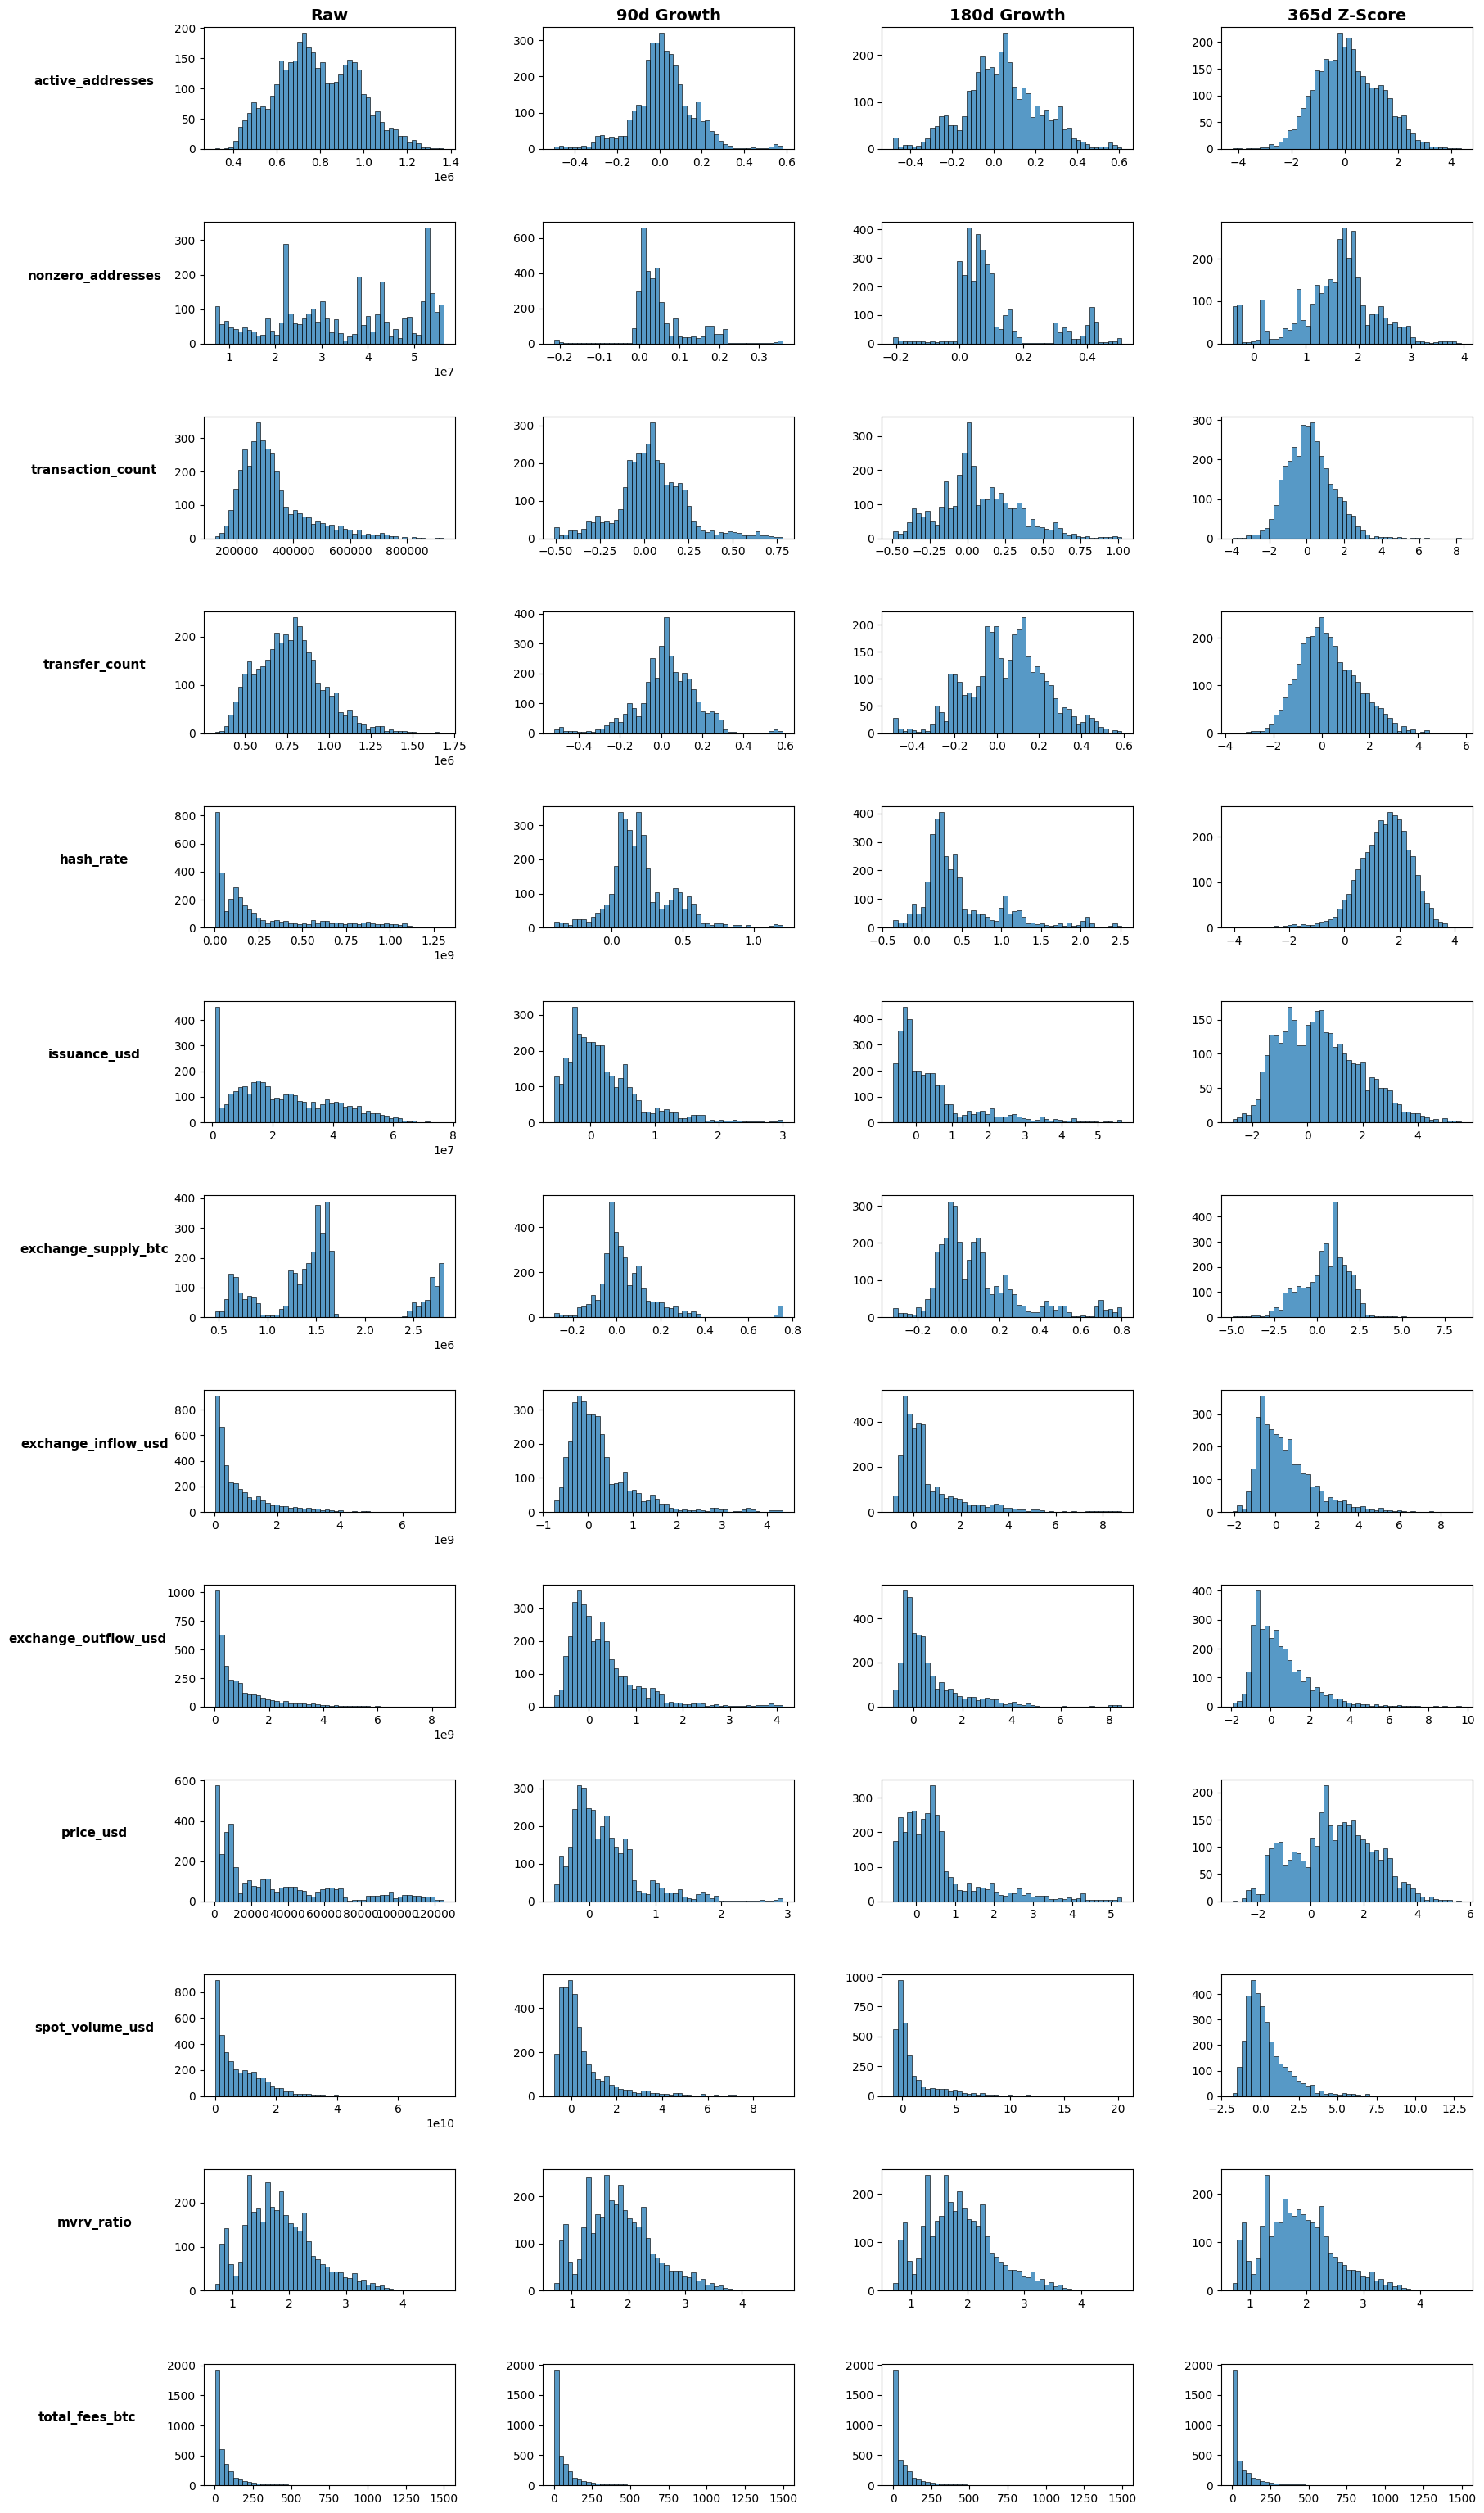

In [155]:
plot_histogram_comparison(
    variables_to_compare
)

**Discussion Histogram Comparison**:

Generally speaking, the results look great. The transformations resulted in much more 'normally' distributed, while also not smoothing out too much, still showing structures other than just noise. Interestingly between the 90d and 180d sets, for some variables A looks more 'normal' and vice versa for some B - indicating that there is no 'one fits all the best' strategy. Whereas the Z-Score results look generally the best considering just distribution in a histogram, with the least spikes and outliers. Mvrv and total fees are shown as a quick robustness check and should be as they are: not transformed.

A quick check on the core questions:

- Are the distributions plausible? -> Yes, very much.
- Is there still structure left, or does it look like random noise? -> Yes, there is always structure left.
- Are there any absurd values? -> No, all distributions look reasonable.

Again, the focus on my project is not on simple distribution but time dependance i.e. can I see different regimes in different time periods, and not just a general trend. Therefore, the next and more important step is to look at the timeseries comparison.

### Timeseries

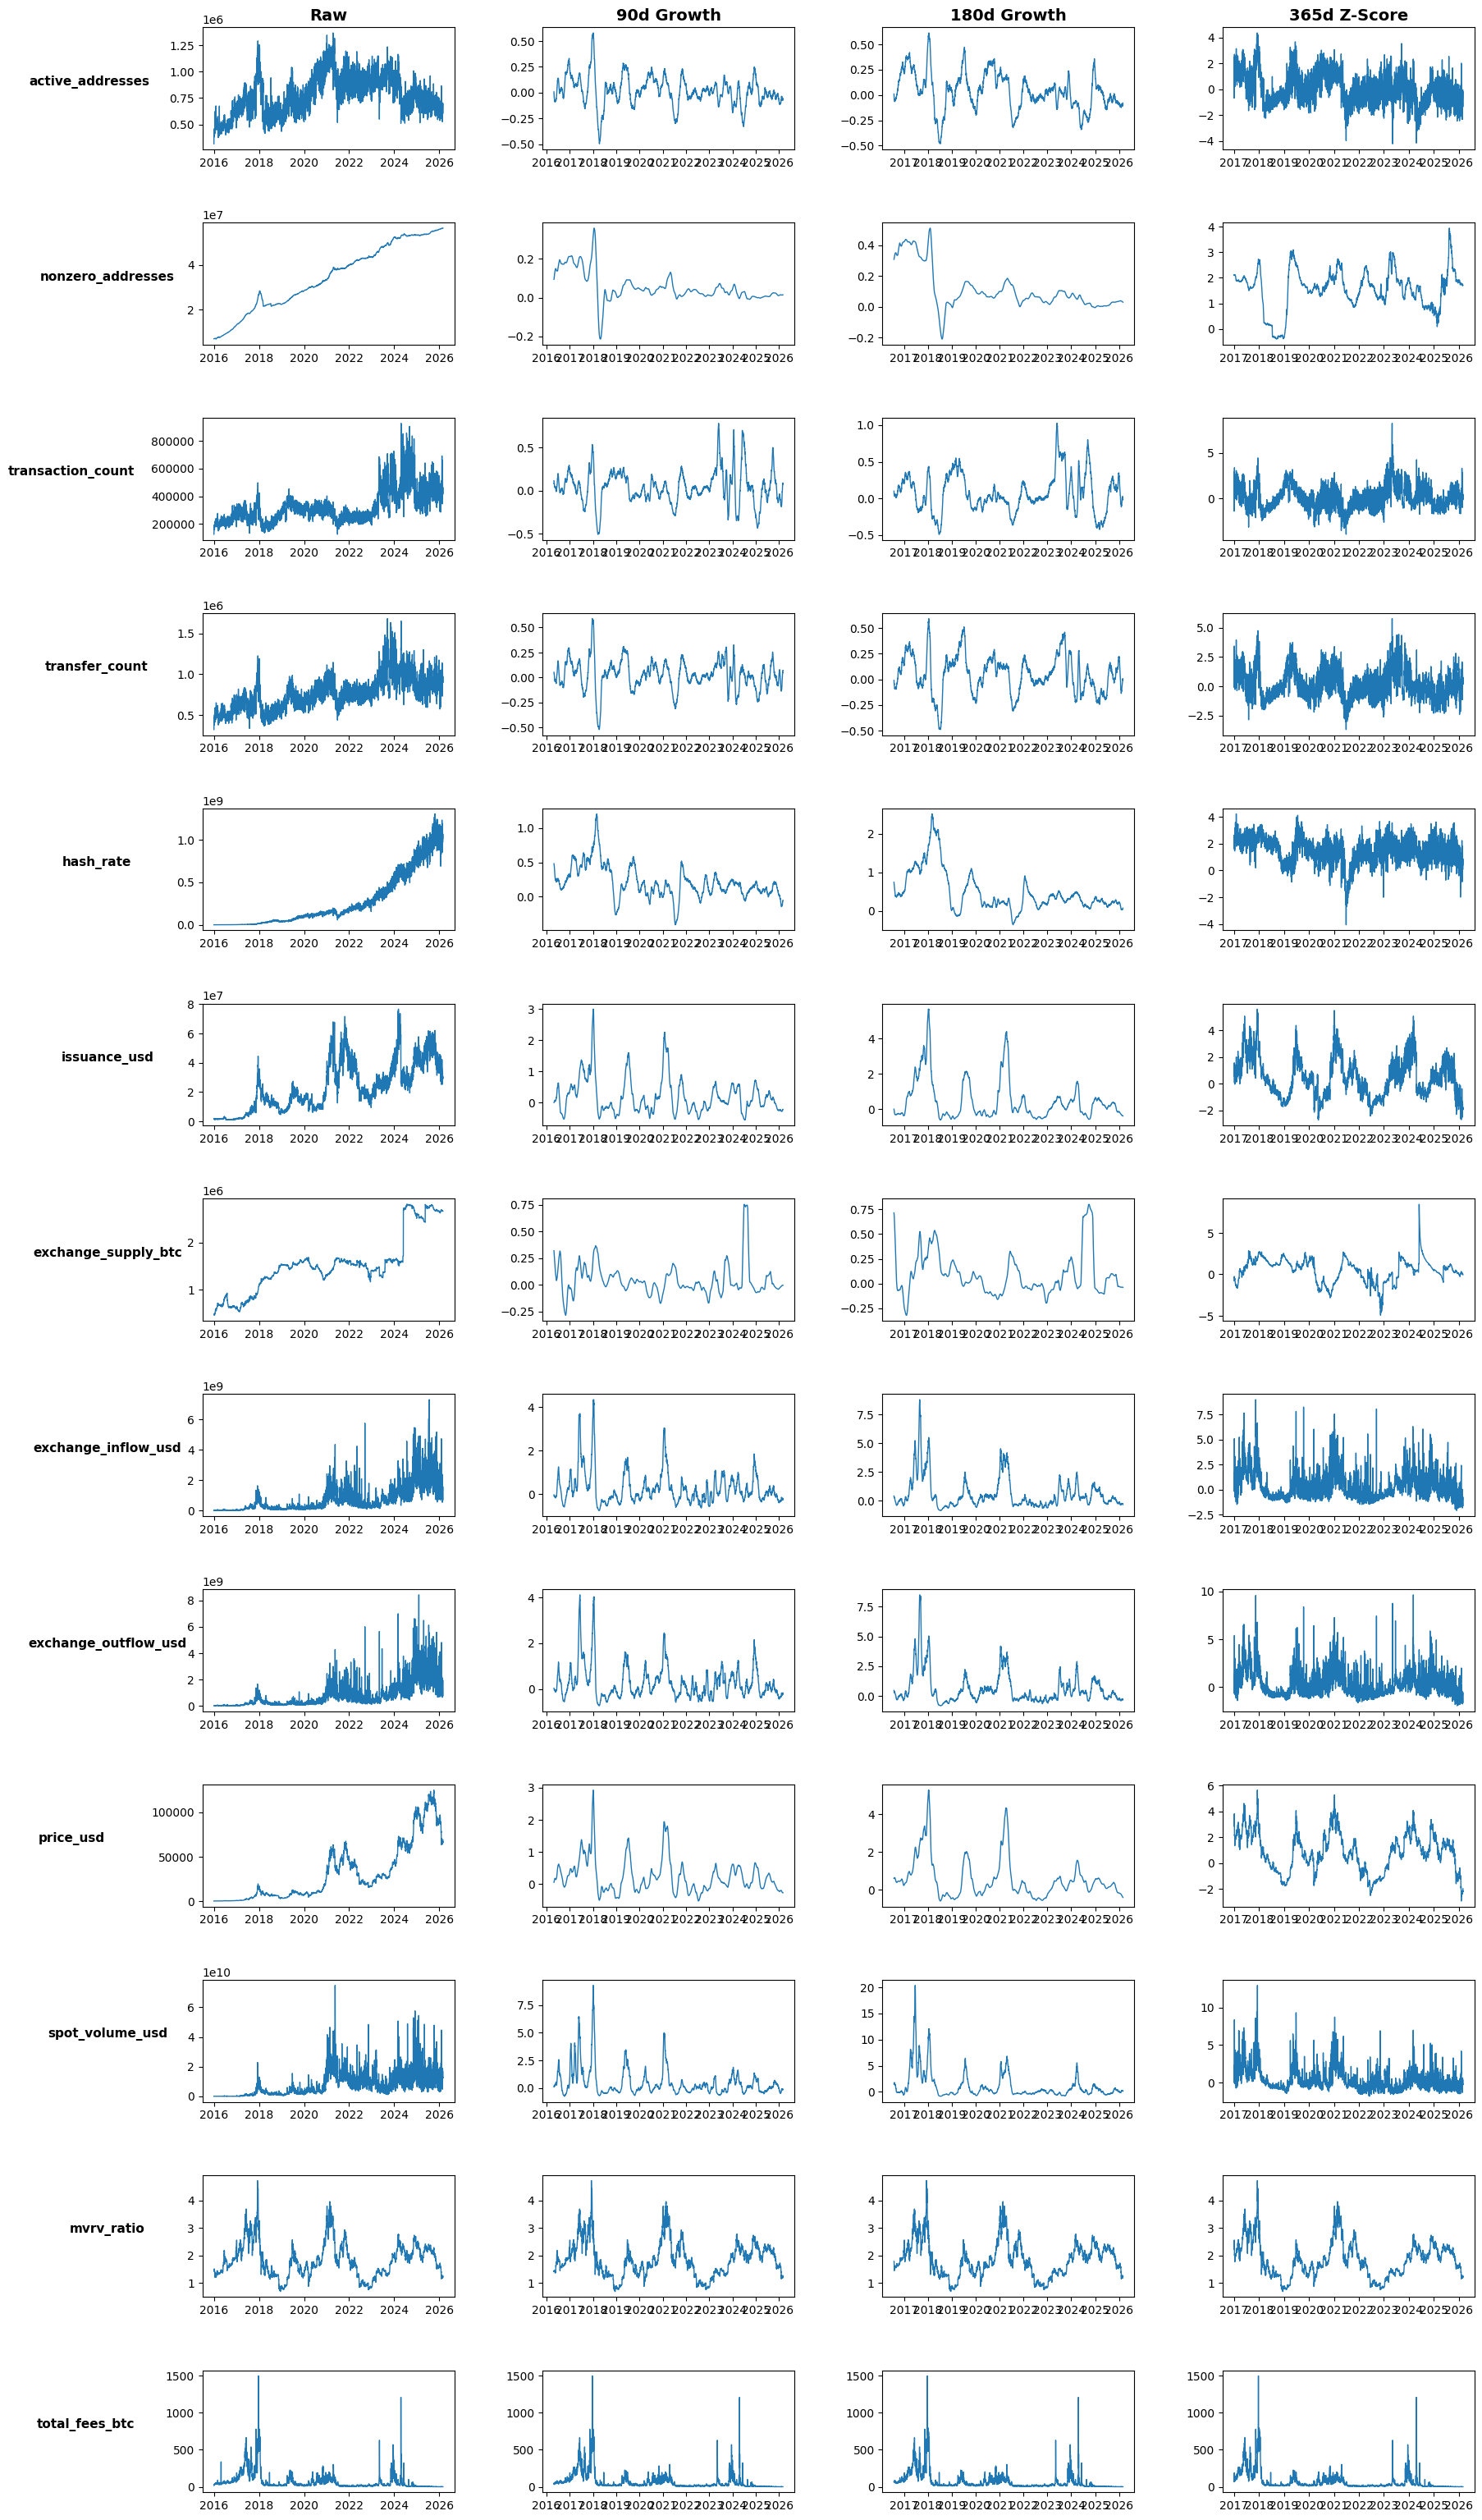

In [156]:
plot_timeseries_comparison(
    variables_to_compare
)

**Discussion Timeseries Comparison**:

The results are very interesting. All variables (except for the non-transformed) look very stationary after transformation - meaning that general trends can not be seen. 

The 90d growth version looks more volatile compared to the 180d growth version, while generally both smooth out the prior very high volatility to a very good degree, leaving mostly smooth functions with spikes that seem to only appear during bull market phases (or during bear market phases, depending on the variable). The structure of different regimes is clearly visible without the prior trend anymore.

The Rolling Z-Score results are generally similar in structure to the Growth-Rate versions, while appearing more stationary while also for some variables, exhibit far higher volatility. This makes sense as I did not apply any MA-smoothing for the Z-Score Transformation, as opposed to for the Growth Rates. Depending on the clustering-results for the dataset C, a possible tweak could be to take an MA 30d approach too, not for the calculation of the standard deviation, but for the value in each observation that is compared to the standard deviation.

There might not be a general trend anymore, but one can see that within the Growth-Rate Datasets, the highs over time seem to keep getting lower, and the general period of 2016-2018 seems to, in some variables (price, hashrate, active addresses and nonzero addresses), have a slightly higher base level compared to the rest. At this stage, it is unclear if this would really affect the quality of clustering, as we're only looking at visualizations here too. Depending on the clusters for sets A and B, a possible tweak could be the exclusion of pre-2019 data. 

Mvrv and bitcoin fees are here again as a quick robustness check. It is unclear how the 'spike' structure will affect the clusterings exactly, and how strong the impact will be. Especially with pure distance based algorithms like K-Means (and with measurements such as sum of squared distances), such spikes might distort the results possibly by quite a big. This should be less a problem for Probability-based algortihms such as GMM, where it could be given a low probability and as such not having a big impact, while Density-based approaches such as DBSCAN could work well with it, as 'useless' spikes would be around low density and as such labelled as outliers. Depending on the results, this variable might be the first candidate to be left out in order to possibly enhance the cluster quality in the later stages, in case that Density-based methods show much better results than Probability-based and Distance-based ones.

A quick check on the core questions again:

- Are the trends gone - do we have approx. stationarity? -> Yes, absolutely.
- Can one still see possible regimes over time? -> Yes, very well.
- Are things too extrapolated by MAs, Growthrates and Z-Scores? -> No, if any, then not enough extrapolated by the Z-Scores

### Conclusion Possible Future Problems and Solutions


- Rolling Z Volatility: High volatility for some variables; If clusters are too local, add MA 30d approach for the observed value before calculating the Z-Score in Dataset C.
- Growth Rates with higher Level during 2016-2018: If these early years become a cluster in Datasets A and B, but not in C, cutting them out might add value for Datasets A and B as these clusters could affect the other clusters too.
- total_fees_btc: High spikes in the data, no smooth regimes; If Density-methods are much better than Probability-based, and Probability-based are better than Distance-based -> Leave this variable possibly out for at least Datasets A and B.

With this, the Feature Validation part is finished and the engineered features are approved. The next step encompasses the exact Feature Selection as some features might not add much information but merely resemble other variables in the dataset. 

### Add-On: Descriptive Tables

For information Purposes, the core descriptive tabels for all 3 datasets: 

#### Dataset A

In [157]:
features_90d.describe().T

,count,mean,min,25%,50%,75%,max,std
date,3595,2021-03-31 00:00:00,2016-04-29 00:00:00,2018-10-14 12:00:00,2021-03-31 00:00:00,2023-09-15 12:00:00,2026-03-02 00:00:00,NaN
active_addresses_ma30_g90d,3595.0,0.01788,-0.496794,-0.050415,0.013976,0.089268,0.580373,0.140713
nonzero_addresses_ma30_g90d,3595.0,0.054236,-0.21333,0.011906,0.034788,0.071182,0.358737,0.076265
transaction_count_ma30_g90d,3595.0,0.037628,-0.508535,-0.066271,0.034033,0.144716,0.780249,0.195853
transfer_count_ma30_g90d,3595.0,0.025814,-0.519441,-0.048626,0.025262,0.113552,0.589056,0.147215
hash_rate_ma30_g90d,3595.0,0.207288,-0.407298,0.069605,0.171909,0.311602,1.205225,0.232717
issuance_usd_ma30_g90d,3595.0,0.194894,-0.567182,-0.212945,0.05708,0.470625,3.001896,0.573922
exchange_supply_btc_ma30_g90d,3595.0,0.045768,-0.28459,-0.030661,0.013974,0.095553,0.755567,0.147732
exchange_inflow_usd_ma30_g90d,3595.0,0.270189,-0.749359,-0.211142,0.086234,0.464765,4.349414,0.750524
exchange_outflow_usd_ma30_g90d,3595.0,0.26483,-0.735796,-0.217135,0.081001,0.505315,4.119466,0.720808


#### Dataset B

In [158]:
features_180d.describe().T

,count,mean,min,25%,50%,75%,max,std
date,3505,2021-05-15 00:00:00,2016-07-28 00:00:00,2018-12-21 00:00:00,2021-05-15 00:00:00,2023-10-08 00:00:00,2026-03-02 00:00:00,NaN
active_addresses_ma30_g180d,3505.0,0.034469,-0.481766,-0.076673,0.032631,0.148644,0.612891,0.183279
nonzero_addresses_ma30_g180d,3505.0,0.111968,-0.208258,0.030362,0.065931,0.138118,0.509965,0.135634
transaction_count_ma30_g180d,3505.0,0.070479,-0.490911,-0.084093,0.028698,0.229348,1.024308,0.258445
transfer_count_ma30_g180d,3505.0,0.046978,-0.48819,-0.063275,0.055729,0.163567,0.590442,0.185034
hash_rate_ma30_g180d,3505.0,0.486239,-0.361624,0.168947,0.308356,0.637812,2.515285,0.525874
issuance_usd_ma30_g180d,3505.0,0.480225,-0.617334,-0.28467,0.081165,0.704355,5.660427,1.146818
exchange_supply_btc_ma30_g180d,3505.0,0.091689,-0.319744,-0.046917,0.042911,0.17546,0.800961,0.21301
exchange_inflow_usd_ma30_g180d,3505.0,0.609652,-0.837338,-0.24886,0.195405,0.887598,8.790528,1.359345
exchange_outflow_usd_ma30_g180d,3505.0,0.593903,-0.819687,-0.241228,0.187599,0.873626,8.496167,1.304408


#### Dataset C

In [159]:
features_z365.describe().T

,count,mean,min,25%,50%,75%,max,std
date,3350,2021-07-31 12:00:00,2016-12-30 00:00:00,2019-04-16 06:00:00,2021-07-31 12:00:00,2023-11-15 18:00:00,2026-03-02 00:00:00,NaN
active_addresses_z365d,3350.0,0.133411,-4.20891,-0.708404,0.063956,0.968932,4.355183,1.199043
nonzero_addresses_z365d,3350.0,1.546405,-0.396122,1.180584,1.652399,1.962195,3.945667,0.785327
transaction_count_z365d,3350.0,0.180811,-3.957297,-0.697053,0.115488,0.936166,8.230011,1.233189
transfer_count_z365d,3350.0,0.262858,-3.704941,-0.598282,0.128785,1.041939,5.7856,1.20608
hash_rate_z365d,3350.0,1.459779,-4.057335,0.887727,1.536738,2.122317,4.233668,0.958367
issuance_usd_z365d,3350.0,0.464917,-2.719351,-0.660534,0.338348,1.416781,5.570853,1.447229
exchange_supply_btc_z365d,3350.0,0.497174,-4.939864,-0.361695,0.679448,1.376972,8.44456,1.39611
exchange_inflow_usd_z365d,3350.0,0.474326,-2.094316,-0.573469,0.151796,1.148184,8.979247,1.398705
exchange_outflow_usd_z365d,3350.0,0.458045,-1.940551,-0.578158,0.15037,1.091034,9.637681,1.381622


## 2.4 Feature Selection

The Feature Selection Step affects the results of Unsupervised Machine Learning greatly. It differs from the selection process in Supervised Machine Learning in that the goal is not to maximize predictive performance, but to keep the underlying structure of the data while avoiding redundant information and, especially in my case, avoiding overrepresentation of specific economic concepts. 

The first goal will be to eliminate redundant information, that is, information that is already present in another variable. To identify these variables, I will use a correlation matrix as a diagnostic tool to identify such highly redundant variables. As a threshhold, I decided to remove variables that show extremely high correlations (above 0.95) and as such, represent nearly identical information.

The next goal is a more implicit one: Overrepresentation of information. Even if the pairwise correlation is not extremely high but lets say 0.7, having many of these variables in the dataset would implicitly assign larger weights to this type of information, and with that affect the clusters directly. Linear dimensionality reduction techniques like PCA as well as non-linear like UMAP find **stronger* directions the more often an information is present, and with that, a dataset with f.e. 10 variables in total but 8 out of those measuring trading demand in a very similar manner will be reduced to primarily the trading demand signals, and assign lower weights to f.e. real consumption demand. 

Lets look at Bitcoin as a direct example - the following table shows the variables in the datasets grouped by what they primarily measure:

| Primary Dimension Measurement | Variables |
|-------------------------------|-----------|
| Demand & Short Term Usage | active_addresses, transaction_count, transfer_count, spot_volume_usd |
| Long Term Demand | nonzero_addresses |
| Valuation | mvrv_ratio, price_usd |
| Supply Economics/Valuation | issuance_usd |
| Mining | hash_rate |
| Exchange Behaviour | exchange_supply_btc, exchange_inflow_usd, exchange_outflow_usd |
| Network Stress | total_fees_btc |

Active Addresses, Transaction Count, Transfer Count, Spot Trading Volume and to some extent Nonzero Addresses all contain information related to primarily demand, while the rest mostly contains information related to other factors within Bitcoin. If I keep this dataset and would assume that all signals in the dataset would have the same strength, then 'demand' as the factor for regime would appear as by far the most dominant and most important signal for finding regimes in the reduced dataset. This is neither bad nor good but dependent on the underlying reality in what factors determine regimes - if demand is indeed more important than the other dimensions, then nothing should be changed accordingly. 
What follows is that not only should redundant information be eliminated before dimensionality reduction, but also should the dataset as a whole represent the different dimensions of relevance in determining different regimes for Bitcoin. This step will be guided by economic interpretation and domain knowledge of Bitcoin while incorporating the correlation patterns. If I do see the necessity of giving less weight to a specific dimension, then I might eliminate the variables in a specific dimension that at the same time contain the most redundant information.

Overall, the goal of feature selection is therefore not to maximize the number of features, but to construct a compact and economically diverse representation of Bitcoin market conditions that allows clustering algorithms to identify meaningful market regimes rather than merely reflecting one dominant aspect of the system. I will achieve this by doing a 2-step selection:

1) I will eliminate variables with >95% Correlation; The one that will be eliminated will be based on a) economic reasoning and b) which of the two variables correlates more with the rest of the dataset as well.

2) I will reduce the dimensions that currently have too much weight, but only if they contain variables with >0.80 correlation inside of that dimension. A 0.80 correlation with the same dimension does not necessarily mean that an elimination is necessary, the primary reason is economic reasoning. I generally do think that Demand is indeed the most important weight and do not see a necessity to reduce there right now. But I do think that probably issuance_usd might not contain enough new information by only incorporating the factor of a changing production function every 4 years, while also probably putting too much weight onto the specific valuation. At the same time, I do think that the behaviour on exchanges should not have such a high impact on regimes as it has right now with 3 variables, and therefore will be cut for sure, especially if the correlations are high. 

I proceed with the 2-step selection for every dataset on its own as the correlations differ after the different transformations. I will derive a correlation matrix for each as an overview and inspect all correlations above the threshold of 0.80.

#### Helper Function

In [160]:
# ============================================================
# Correlation analysis helper function
# ============================================================

def correlation_analysis(features_df, title, threshold=0.90):
    feature_cols = [col for col in features_df.columns if col != "date"]

    corr_matrix = features_df[feature_cols].corr()

    plt.figure(figsize=(12, 10))

    sns.heatmap(
        corr_matrix,
        cmap="coolwarm",
        center=0,
        square=True
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()

    corr_pairs = (
        corr_matrix
        .abs()
        .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
    )

    print(f"Top correlations above {threshold}:")
    display(corr_pairs[corr_pairs > threshold])

    return corr_matrix, corr_pairs

### Correlation Analysis: Dataset A (90d Growth with 30d MA)

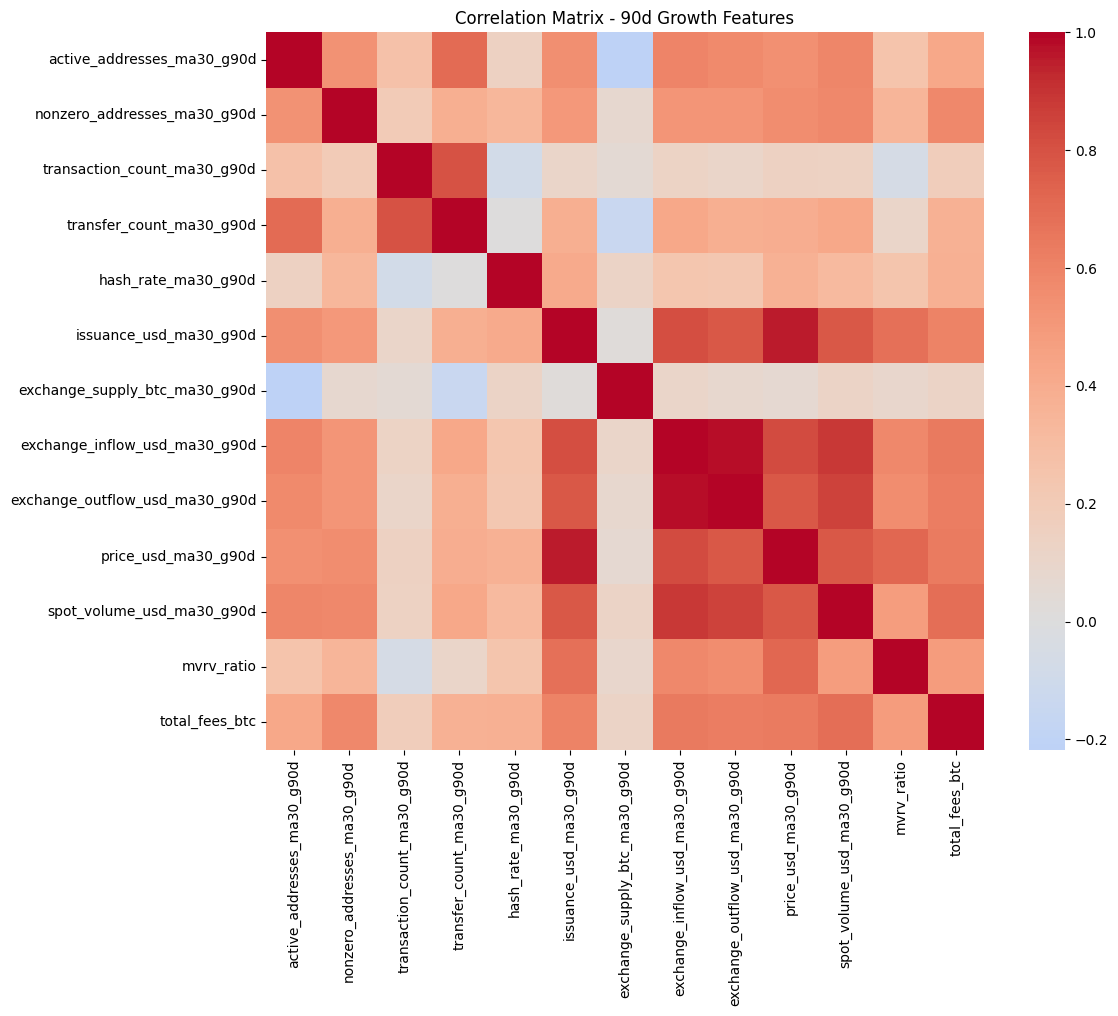

Top correlations above 0.8:


exchange_inflow_usd_ma30_g90d   exchange_outflow_usd_ma30_g90d    0.976737
issuance_usd_ma30_g90d          price_usd_ma30_g90d               0.955812
exchange_inflow_usd_ma30_g90d   spot_volume_usd_ma30_g90d         0.884495
exchange_outflow_usd_ma30_g90d  spot_volume_usd_ma30_g90d         0.854473
exchange_inflow_usd_ma30_g90d   price_usd_ma30_g90d               0.820382
issuance_usd_ma30_g90d          exchange_inflow_usd_ma30_g90d     0.813640
transaction_count_ma30_g90d     transfer_count_ma30_g90d          0.802603
dtype: float64

In [161]:
corr_90d, corr_pairs_90d = correlation_analysis(
    features_90d,
    "Correlation Matrix - 90d Growth Features",
    threshold=0.80
)

#### Conclusion

**To eliminate**:

Due to redundant information:
- **exchange_inflow_usd**: 0.976 correlation with exchange_outflow, but inflow correlates higher with other variables than outflow
- **issuance_usd**: above 0.95

Due to dimension representation:
- **NONE**: The high correlations already eliminated variables that would have put on too much weight on specific dimensions.

#### Elimination and Saving Final Dataset

In [162]:
# ============================================================
# Dataset A: final feature selection
# ============================================================

features_90d = features_90d.drop(
    columns=[
        "issuance_usd_ma30_g90d",
        "exchange_inflow_usd_ma30_g90d"
    ]
)

print(features_90d.shape)
features_90d.columns.tolist()

(3595, 12)


['date',
 'active_addresses_ma30_g90d',
 'nonzero_addresses_ma30_g90d',
 'transaction_count_ma30_g90d',
 'transfer_count_ma30_g90d',
 'hash_rate_ma30_g90d',
 'exchange_supply_btc_ma30_g90d',
 'exchange_outflow_usd_ma30_g90d',
 'price_usd_ma30_g90d',
 'spot_volume_usd_ma30_g90d',
 'mvrv_ratio',
 'total_fees_btc']

In [163]:
# ============================================================
# Save final Dataset A
# ============================================================

features_90d.to_csv(
    "../data/processed/features_90d_final.csv",
    index=False
)

print("Dataset A saved.")

Dataset A saved.


### Correlation Analysis: Dataset B (180d Growth with 30d MA)

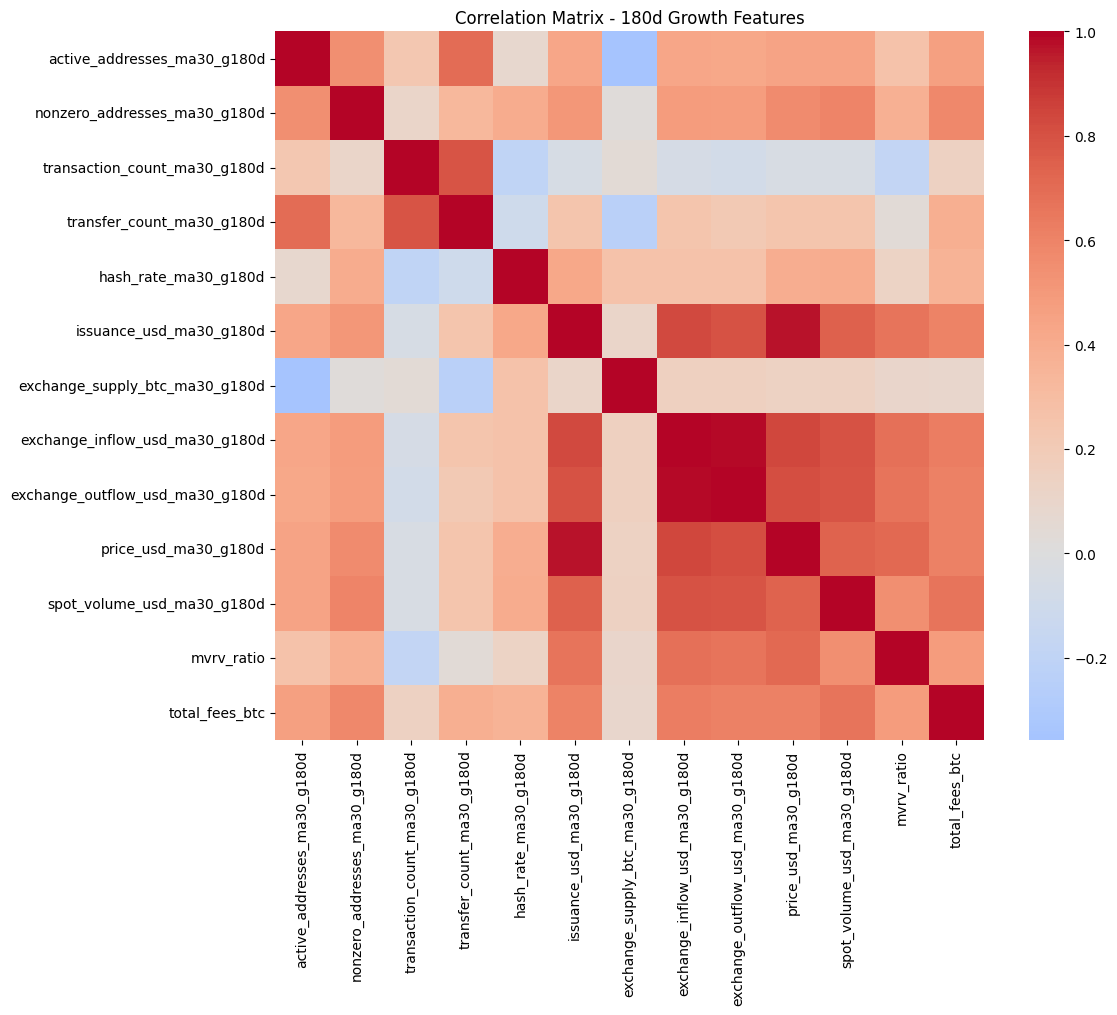

Top correlations above 0.8:


exchange_inflow_usd_ma30_g180d   exchange_outflow_usd_ma30_g180d    0.989240
issuance_usd_ma30_g180d          price_usd_ma30_g180d               0.971412
exchange_inflow_usd_ma30_g180d   price_usd_ma30_g180d               0.840799
issuance_usd_ma30_g180d          exchange_inflow_usd_ma30_g180d     0.826558
exchange_outflow_usd_ma30_g180d  price_usd_ma30_g180d               0.815854
exchange_inflow_usd_ma30_g180d   spot_volume_usd_ma30_g180d         0.803515
dtype: float64

In [164]:
corr_180d, corr_pairs_180d = correlation_analysis(
    features_180d,
    "Correlation Matrix - 180d Growth Features",
    threshold=0.80
)

#### Conclusion

**To eliminate**: Exactly the same variables as with the Dataset A

Due to redundant information:
- **exchange_inflow_usd**: 0.989 correlation with exchange_outflow, but inflow correlates higher with other variables than outflow
- **issuance_usd**: above 0.971

Due to dimension representation:
- **NONE**: The high correlations already eliminated variables that would have put on too much weight on specific dimensions.

#### Elimination and Saving Final Dataset

In [165]:
# ============================================================
# Dataset B: final feature selection
# ============================================================

features_180d = features_180d.drop(
    columns=[
        "issuance_usd_ma30_g180d",
        "exchange_inflow_usd_ma30_g180d"
    ]
)

print(features_180d.shape)
features_180d.columns.tolist()

(3505, 12)


['date',
 'active_addresses_ma30_g180d',
 'nonzero_addresses_ma30_g180d',
 'transaction_count_ma30_g180d',
 'transfer_count_ma30_g180d',
 'hash_rate_ma30_g180d',
 'exchange_supply_btc_ma30_g180d',
 'exchange_outflow_usd_ma30_g180d',
 'price_usd_ma30_g180d',
 'spot_volume_usd_ma30_g180d',
 'mvrv_ratio',
 'total_fees_btc']

In [166]:
# ============================================================
# Save final Dataset B
# ============================================================

features_180d.to_csv(
    "../data/processed/features_180d_final.csv",
    index=False
)

print("Dataset B saved.")

Dataset B saved.


### Correlation Analysis: Dataset C (Rolling Z-Scores 365d)

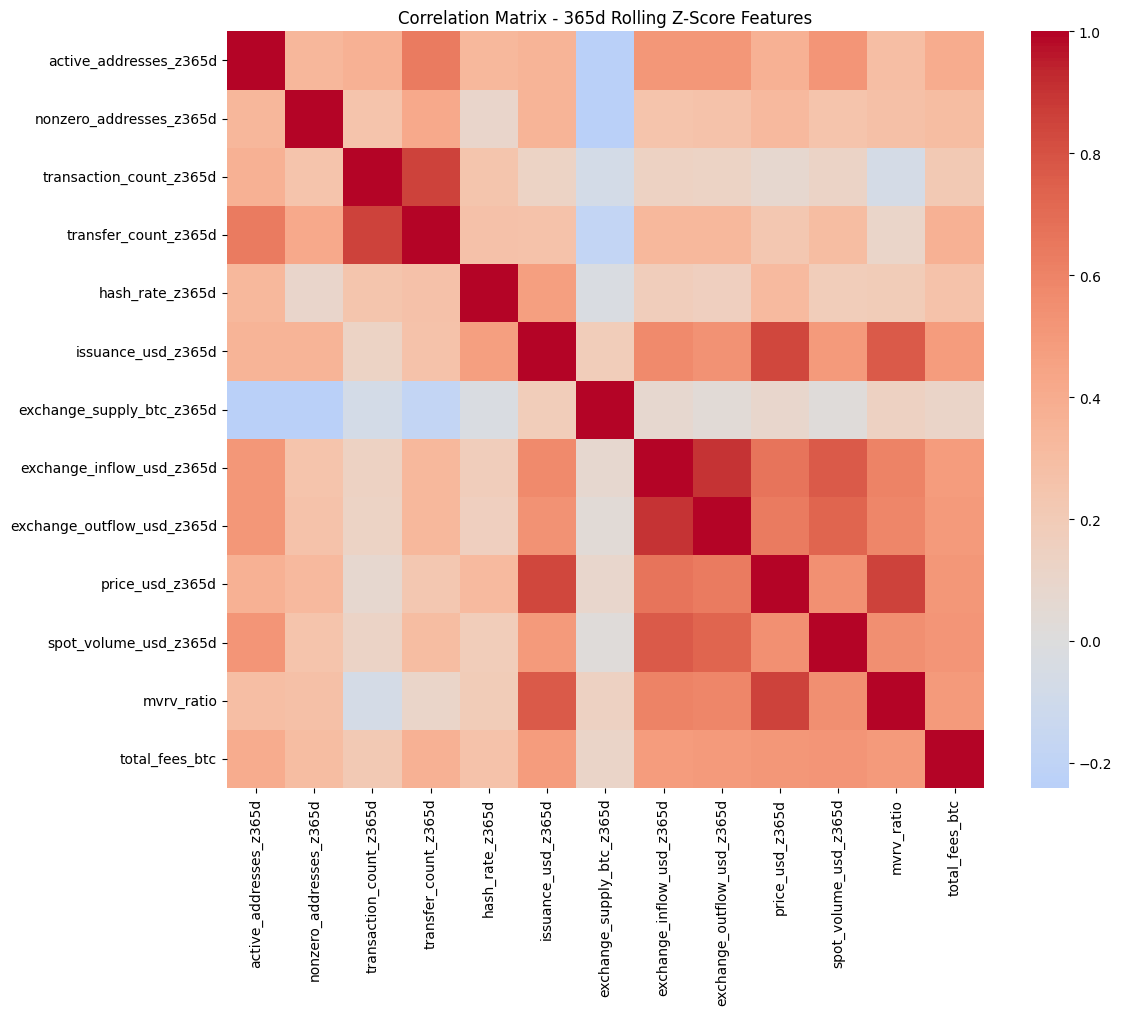

Top correlations above 0.8:


exchange_inflow_usd_z365d  exchange_outflow_usd_z365d    0.898224
price_usd_z365d            mvrv_ratio                    0.858659
transaction_count_z365d    transfer_count_z365d          0.855613
issuance_usd_z365d         price_usd_z365d               0.838251
dtype: float64

In [167]:
corr_z365, corr_pairs_z365 = correlation_analysis(
    features_z365,
    "Correlation Matrix - 365d Rolling Z-Score Features",
    threshold=0.80
)

#### Conclusion

**To eliminate**:

Due to redundant information:
- **NONE**: Highest correlation at 0.898

Due to dimension representation:
- **exchange_inflow_usd**: 0.898 correlation with exchange_outflow, but generally putting too much weight onto exchange in and outflows, therefore inflow eliminated due to also having higher correlations with the rest of the variables compared to outflow.

#### Elimination and Saving Final Dataset

In [168]:
# ============================================================
# Dataset C: final feature selection
# ============================================================

features_z365 = features_z365.drop(
    columns=[
        "exchange_inflow_usd_z365d"
    ]
)

print(features_z365.shape)
features_z365.columns.tolist()

(3350, 13)


['date',
 'active_addresses_z365d',
 'nonzero_addresses_z365d',
 'transaction_count_z365d',
 'transfer_count_z365d',
 'hash_rate_z365d',
 'issuance_usd_z365d',
 'exchange_supply_btc_z365d',
 'exchange_outflow_usd_z365d',
 'price_usd_z365d',
 'spot_volume_usd_z365d',
 'mvrv_ratio',
 'total_fees_btc']

In [169]:
# ============================================================
# Save final Dataset C
# ============================================================

features_z365.to_csv(
    "../data/processed/features_z365_final.csv",
    index=False
)

print("Dataset C saved.")

Dataset C saved.


## 2.5 Feature Scaling

Before applying dimensionality reduction and clustering methods on the selected datasets, all features have to be scaled first.
This step is necessary because all dimensionality reduction and clustering methods used in this project rely on distances between observations. Without scaling, variables with larger numerical ranges would dominate the analysis and distort the resulting embeddings and clusters. Therefore, the scales are standardized using the StandardScaler transformation.

StandardScaler transforms each feature to a mean of zero and a standard deviation of one, ensuring that all variables contribute equally to the analysis while preserving their underlying information.

I will apply the scaling separately to each feature set. The scaled datasets are ready for the dimensionality reduction.

### Scaling A

In [170]:
# ============================================================
# Scaling Dataset A
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler_A = StandardScaler()

X_A = features_90d.drop(columns=["date"])

X_A_scaled = pd.DataFrame(
    scaler_A.fit_transform(X_A),
    columns=X_A.columns
)

X_A_scaled["date"] = features_90d["date"]

print(X_A_scaled.shape)

X_A_scaled.head()

(3595, 12)


,active_addresses_ma30_g90d,nonzero_addresses_ma30_g90d,transaction_count_ma30_g90d,transfer_count_ma30_g90d,hash_rate_ma30_g90d,exchange_supply_btc_ma30_g90d,exchange_outflow_usd_ma30_g90d,price_usd_ma30_g90d,spot_volume_usd_ma30_g90d,mvrv_ratio,total_fees_btc,date
0,-0.070493,0.526633,0.389656,0.184156,1.176724,1.863207,-0.319936,-0.345774,-0.281198,-0.649376,-0.194821,2016-04-29
1,-0.147224,0.547752,0.344375,0.137449,1.128921,1.800561,-0.342407,-0.329367,-0.269605,-0.685412,-0.268641,2016-04-30
2,-0.282690,0.576964,0.253002,0.092861,1.095994,1.734955,-0.395314,-0.313027,-0.279554,-0.662208,-0.335303,2016-05-01
3,-0.418139,0.615761,0.196567,0.047952,1.058239,1.672555,-0.415649,-0.299510,-0.234660,-0.712827,-0.231850,2016-05-02
4,-0.475467,0.661445,0.239871,0.051508,1.053327,1.606682,-0.406563,-0.283472,-0.212802,-0.680203,-0.238979,2016-05-03


### Scaling B

In [171]:
# ============================================================
# Scaling Dataset B
# ============================================================

scaler_B = StandardScaler()

X_B = features_180d.drop(columns=["date"])

X_B_scaled = pd.DataFrame(
    scaler_B.fit_transform(X_B),
    columns=X_B.columns
)

X_B_scaled["date"] = features_180d["date"]

print(X_B_scaled.shape)

X_B_scaled.head()

(3505, 12)


,active_addresses_ma30_g180d,nonzero_addresses_ma30_g180d,transaction_count_ma30_g180d,transfer_count_ma30_g180d,hash_rate_ma30_g180d,exchange_supply_btc_ma30_g180d,exchange_outflow_usd_ma30_g180d,price_usd_ma30_g180d,spot_volume_usd_ma30_g180d,mvrv_ratio,total_fees_btc,date
0,-0.132798,1.444243,0.110838,-0.308519,0.485058,2.925534,-0.096149,0.032312,0.199057,-0.105986,0.006006,2016-07-28
1,-0.199256,1.454870,0.074621,-0.381498,0.439425,2.893474,-0.128313,0.042127,0.182487,-0.102010,0.002160,2016-07-29
2,-0.295429,1.469559,-0.000163,-0.438335,0.391559,2.859550,-0.188050,0.048515,0.150009,-0.113171,-0.046417,2016-07-30
3,-0.400162,1.488002,-0.075779,-0.510980,0.353757,2.835277,-0.229388,0.051616,0.153275,-0.241598,0.018417,2016-07-31
4,-0.419924,1.510745,-0.062545,-0.494036,0.343059,2.814757,-0.240274,0.052411,0.168571,-0.316880,-0.011435,2016-08-01


### Scaling C

In [172]:
# ============================================================
# Scaling Dataset C
# ============================================================

scaler_C = StandardScaler()

X_C = features_z365.drop(columns=["date"])

X_C_scaled = pd.DataFrame(
    scaler_C.fit_transform(X_C),
    columns=X_C.columns
)

X_C_scaled["date"] = features_z365["date"]

print(X_C_scaled.shape)

X_C_scaled.head()

(3350, 13)


,active_addresses_z365d,nonzero_addresses_z365d,transaction_count_z365d,transfer_count_z365d,hash_rate_z365d,issuance_usd_z365d,exchange_supply_btc_z365d,exchange_outflow_usd_z365d,price_usd_z365d,spot_volume_usd_z365d,mvrv_ratio,total_fees_btc,date
0,1.329662,0.716076,1.270221,1.280017,1.015424,0.292440,-0.903591,0.631619,1.351908,1.056775,0.574043,0.241570,2016-12-30
1,0.509991,0.725070,0.340155,0.656094,0.628944,0.132291,-0.862335,-0.671912,1.362706,-0.273288,0.595816,0.080301,2016-12-31
2,-0.680496,0.707673,-1.297866,-0.295704,0.943515,0.386380,-0.816072,-0.804144,1.467586,0.107484,0.684777,-0.030983,2017-01-01
3,1.943047,0.691961,1.379713,2.219555,1.047383,0.512085,-0.779530,0.104086,1.528232,1.331190,0.736257,0.320972,2017-01-02
4,1.584761,0.705793,1.839706,2.630761,1.224468,0.670662,-0.694354,0.771076,1.565838,0.876961,0.770989,0.434778,2017-01-03


### Save Scaled Datasets

In [173]:
X_A_scaled.to_csv(
    "../data/processed/X_A_scaled.csv",
    index=False
)

X_B_scaled.to_csv(
    "../data/processed/X_B_scaled.csv",
    index=False
)

X_C_scaled.to_csv(
    "../data/processed/X_C_scaled.csv",
    index=False
)